### **Machine Learning for Data Analytics**
### **Assignment 2**
#### Piotr Czech, Filip Miśkiewicz

### **Imports**

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import dice_ml
import shap
import torch
import seaborn as sns
import skimage
import optuna
import datasets

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from PIL import Image
from torchvision import models
from torchvision.models import ResNet50_Weights
from torch.utils.data import DataLoader
from lime import lime_image
from skimage.segmentation import mark_boundaries, slic
from functools import partial
from tqdm.auto import tqdm

In [2]:
random_state = 333

### **Task 1**

In this excercise we are presenting SHAP analysis for `RandomForestClassifier`. We use file `adult-income-dataset.csv`, so now lets load up data and clean them by droping null values.

In [ ]:
adult_income_df = pd.read_csv('./../datasets/adult-income-dataset.csv')
adult_income_df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [ ]:
adult_income_df = adult_income_df.replace("?", np.nan)

before_dropna = adult_income_df.shape
adult = adult_income_df.dropna().copy()
after_dropna = adult.shape

print(f"Before dropping nan values: {before_dropna}")
print(f"After dropping nan values: {after_dropna}")

Before dropping nan values: (48842, 15)
After dropping nan values: (45222, 15)


Now we divide data into input features and target (income) column.

In [ ]:
adult['income'].unique()

<StringArray>
['<=50K', '>50K']
Length: 2, dtype: str

As we see target is binary: `$<=50K = 0$` and `$>50K = 1$`.

In [ ]:
adult["income"] = adult["income"].map({"<=50K": 0, ">50K": 1})

Becouse dataset contains many categorical columns, we need to check it.

In [ ]:
categorical_cols = X.select_dtypes(include="str").columns.tolist()
numeric_cols = X.select_dtypes(exclude="object").columns.tolist()

print(f"Categorical columns: {categorical_cols}")
print(f"Numeric columns: {numeric_cols}")

Categorical columns: ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country']
Numeric columns: ['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']


In [ ]:
adult[categorical_cols].head()

,workclass,marital-status,occupation,relationship,race,gender,native-country
0,Private,Never-married,Machine-op-inspct,Own-child,Black,Male,United-States
1,Private,Married-civ-spouse,Farming-fishing,Husband,White,Male,United-States
2,Local-gov,Married-civ-spouse,Protective-serv,Husband,White,Male,United-States
3,Private,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,United-States
5,Private,Never-married,Other-service,Not-in-family,White,Male,United-States


In [ ]:
adult[['education', 'educational-num']].head()

,education,educational-num
0,11th,7
1,HS-grad,9
2,Assoc-acdm,12
3,Some-college,10
5,10th,6


This one ordinal category is also written in number (we suppose), so lets drop it.

In [ ]:
adult.drop(columns=["education"], inplace=True)
adult.columns

Index(['age', 'workclass', 'fnlwgt', 'educational-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'income'],
      dtype='str')

Lets check one more propably big column `native-country`

In [ ]:
adult['native-country'].unique()

<StringArray>
[             'United-States',                       'Peru',
                  'Guatemala',                     'Mexico',
         'Dominican-Republic',                    'Ireland',
                    'Germany',                'Philippines',
                   'Thailand',                      'Haiti',
                'El-Salvador',                'Puerto-Rico',
                    'Vietnam',                      'South',
                   'Columbia',                      'Japan',
                      'India',                   'Cambodia',
                     'Poland',                       'Laos',
                    'England',                       'Cuba',
                     'Taiwan',                      'Italy',
                     'Canada',                   'Portugal',
                      'China',                  'Nicaragua',
                   'Honduras',                       'Iran',
                   'Scotland',                    'Jamaica',
          

It seems too much for nice simple decision tree, so I with the power of AI (like solution when maybe there is 200 unique values), we divide them into groups by region.

In [ ]:
def map_country_to_region(country):
    europe = {
        "England", "Germany", "Greece", "Italy", "Poland", "Portugal",
        "France", "Ireland", "Scotland", "Hungary", "Yugoslavia",
        "Holand-Netherlands"
    }
    
    asia = {
        "India", "Japan", "China", "Iran", "Philippines", "Vietnam",
        "Cambodia", "Thailand", "Laos", "Taiwan", "Hong", "South"
    }
    
    latin_america = {
        "Mexico", "Puerto-Rico", "Honduras", "Jamaica", "Cuba",
        "Dominican-Republic", "El-Salvador", "Guatemala", "Haiti",
        "Nicaragua", "Peru", "Ecuador", "Trinadad&Tobago", "Columbia"
    }
    
    if country == "United-States":
        return "United-States"
    elif country in europe:
        return "Europe"
    elif country in asia:
        return "Asia"
    elif country in latin_america:
        return "Latin-America"
    else:
        return "Other"

In [ ]:
adult["native-country"] = adult["native-country"].apply(map_country_to_region)
adult.head()

,age,workclass,fnlwgt,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,89814,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,336951,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,160323,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
5,34,Private,198693,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,0


In [ ]:
adult['native-country'].unique()

<StringArray>
['United-States', 'Latin-America', 'Europe', 'Asia', 'Other']
Length: 5, dtype: str

Everything else seems okey to use one hot encoding.

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
    ],
    verbose_feature_names_out=False
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=random_state,
    stratify=y
)

print(f"Train set: {X_train.shape}, {y_train.shape}")
print(f"Test set: {X_test.shape}, {y_test.shape}")

Train set: (36177, 13), (36177,)
Test set: (9045, 13), (9045,)


In [ ]:
X = adult.drop(columns=["income"])
y = adult["income"]

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=feature_names, index=X_train.index)
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=feature_names, index=X_test.index)

X_train_encoded_df.head()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,...,race_Black,race_Other,race_White,gender_Female,gender_Male,native-country_Asia,native-country_Europe,native-country_Latin-America,native-country_Other,native-country_United-States
19133,54.0,32778.0,9.0,0.0,0.0,30.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4784,74.0,148867.0,10.0,6418.0,0.0,24.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
47510,29.0,176037.0,11.0,14344.0,0.0,40.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3097,36.0,126675.0,13.0,0.0,0.0,45.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1936,41.0,194537.0,13.0,0.0,0.0,40.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
print(feature_names)

['age' 'fnlwgt' 'educational-num' 'capital-gain' 'capital-loss'
 'hours-per-week' 'workclass_Federal-gov' 'workclass_Local-gov'
 'workclass_Private' 'workclass_Self-emp-inc' 'workclass_Self-emp-not-inc'
 'workclass_State-gov' 'workclass_Without-pay' 'marital-status_Divorced'
 'marital-status_Married-AF-spouse' 'marital-status_Married-civ-spouse'
 'marital-status_Married-spouse-absent' 'marital-status_Never-married'
 'marital-status_Separated' 'marital-status_Widowed'
 'occupation_Adm-clerical' 'occupation_Armed-Forces'
 'occupation_Craft-repair' 'occupation_Exec-managerial'
 'occupation_Farming-fishing' 'occupation_Handlers-cleaners'
 'occupation_Machine-op-inspct' 'occupation_Other-service'
 'occupation_Priv-house-serv' 'occupation_Prof-specialty'
 'occupation_Protective-serv' 'occupation_Sales' 'occupation_Tech-support'
 'occupation_Transport-moving' 'relationship_Husband'
 'relationship_Not-in-family' 'relationship_Other-relative'
 'relationship_Own-child' 'relationship_Unmarried' '

Then we train Random Forest classifier. We also check simple metrics, just to verify that model works correctly.

In [ ]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 600, step=100),
        "max_depth": trial.suggest_int("max_depth", 4, 12),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "random_state": random_state,
        "n_jobs": -1
    }

    model = RandomForestClassifier(**params)

    scores = cross_val_score(
        model,
        X_train_encoded_df,
        y_train,
        cv=3,
        scoring="roc_auc",
        n_jobs=-1
    )
    
    return scores.mean()

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print("Best score:", study.best_value)
print("Best params:", study.best_params)

[I 2026-03-06 19:05:01,753] A new study created in memory with name: no-name-4ae9e306-3996-4562-85f3-52e9e8346fd7
[I 2026-03-06 19:05:03,292] Trial 0 finished with value: 0.8951746600017927 and parameters: {'n_estimators': 200, 'max_depth': 4, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.8951746600017927.
[I 2026-03-06 19:05:07,806] Trial 1 finished with value: 0.9102282314377076 and parameters: {'n_estimators': 600, 'max_depth': 7, 'min_samples_split': 13, 'min_samples_leaf': 2, 'max_features': None}. Best is trial 1 with value: 0.9102282314377076.
[I 2026-03-06 19:05:10,050] Trial 2 finished with value: 0.9001963283473383 and parameters: {'n_estimators': 600, 'max_depth': 5, 'min_samples_split': 17, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.9102282314377076.
[I 2026-03-06 19:05:12,296] Trial 3 finished with value: 0.9040294859437247 and parameters: {'n_estimators': 600, 'max_depth': 6, 'min_s

Best score: 0.9131254128497012
Best params: {'n_estimators': 500, 'max_depth': 12, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'log2'}


In [ ]:
rf_model = RandomForestClassifier(
    **study.best_params,
    random_state=random_state,
    n_jobs=-1
)

rf_model.fit(X_train_encoded_df, y_train)

y_pred = rf_model.predict(X_test_encoded_df)
y_proba = rf_model.predict_proba(X_test_encoded_df)[:, 1]

And display the results

In [ ]:
print(f"accuracy {accuracy_score(y_test, y_pred):.4f}")

accuracy 0.8568


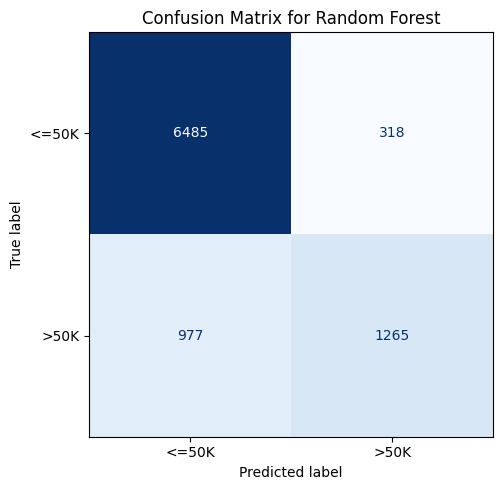

In [ ]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["<=50K", ">50K"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)

plt.title("Confusion Matrix for our model")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

Now we calculate SHAP values for all test samples. For binary classification SHAP can return values for both classes, so we keep explanation for positive class `$>50K$`.

In [ ]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer(X_test_encoded_df)

if len(shap_values.values.shape) == 3:
    shap_values_pos = shap_values[:, :, 1]
else:
    shap_values_pos = shap_values

print("SHAP values shape for class >50K:", shap_values_pos.values.shape)

SHAP values shape for class >50K: (9045, 52)


lets visualize

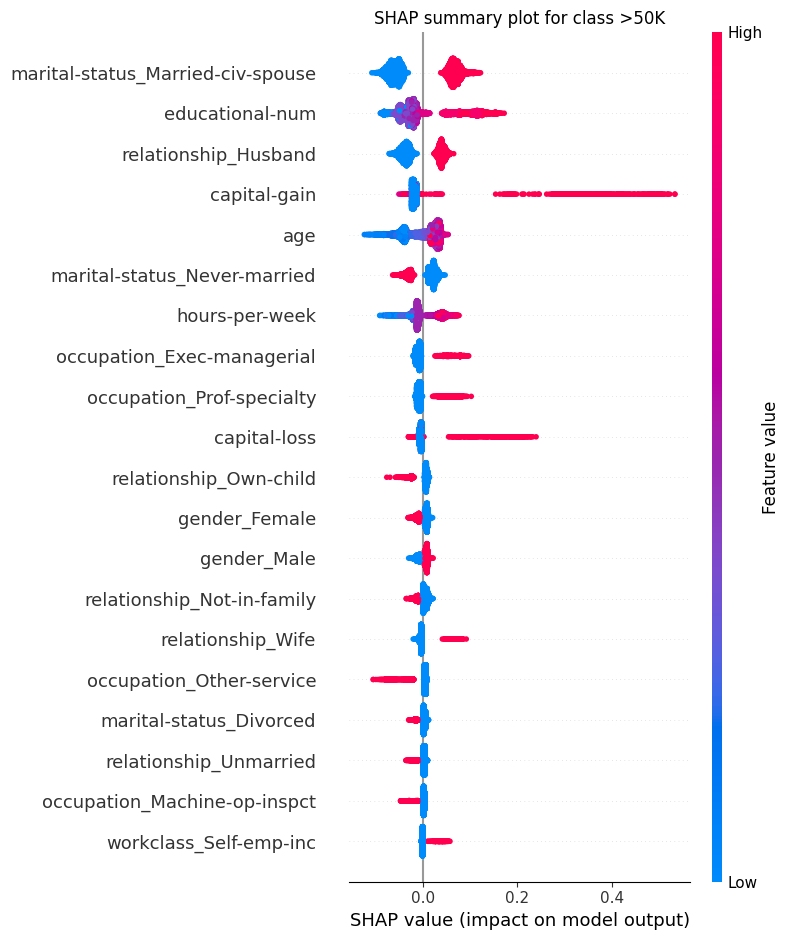

In [ ]:
plt.figure()
shap.summary_plot(shap_values_pos, X_test_encoded_df, show=False)
plt.title("SHAP summary plot for class >50K")
plt.tight_layout()
plt.show()

plot shows that the most important features in the model are mostly related to marital status, education, relationship, capital gain, and age.

The strongest positive impact on prediction of class `>50K` can be seen for `marital-status_Married-civ-spouse`, higher `educational-num`, high `capital-gain`, and some occupation categories such as `Exec-managerial` and `Prof-specialty`.

In general, the model predicts higher income mainly for people with higher education, strong capital gains, and more stable family or work-related status. Lower income is more often associated with categories linked to weaker labor market position or less favorable personal status.

From SHAP values we can also calculate global importance numerically. We take mean absolute SHAP value for every feature and sort them descending.

Below we show top 5 most important features globally.

In [ ]:
global_importance = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": np.abs(shap_values_pos.values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

top5_features = global_importance.head(5).reset_index(drop=True)
display(top5_features)

,feature,mean_abs_shap
0,marital-status_Married-civ-spouse,0.064265
1,educational-num,0.048749
2,relationship_Husband,0.038769
3,capital-gain,0.035895
4,age,0.030603


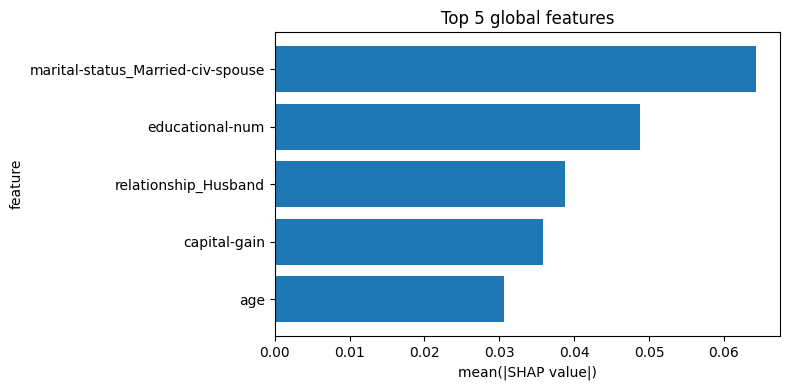

In [ ]:
plt.figure(figsize=(8, 4))
plt.barh(top5_features["feature"][::-1], top5_features["mean_abs_shap"][::-1])
plt.xlabel("mean(|SHAP value|)")
plt.ylabel("feature")
plt.title("Top 5 global features")
plt.tight_layout()
plt.show()

To better understand individual features, we draw dependence plots. We use the three strongest features from global ranking.

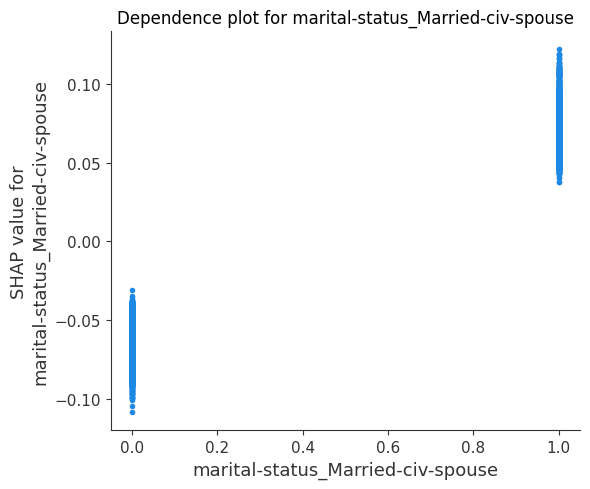

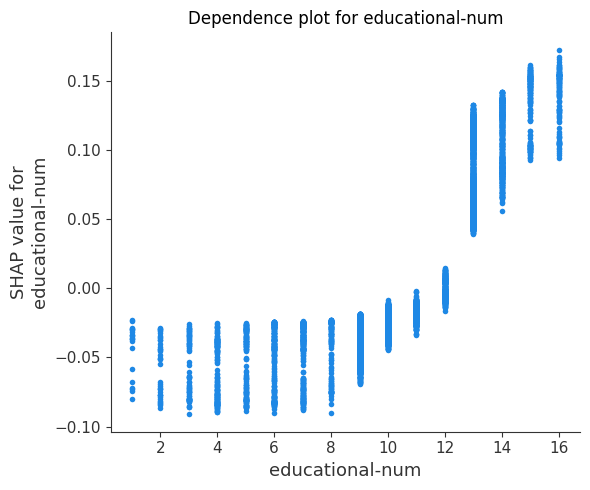

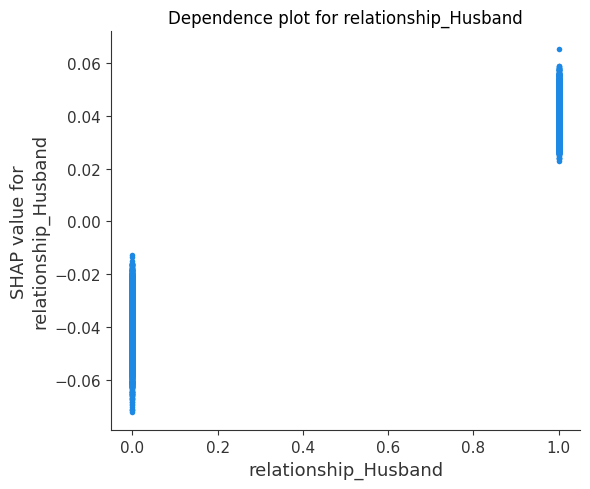

In [ ]:
top3_feature_names = top5_features["feature"].head(3).tolist()

for feature in top3_feature_names:
    shap.dependence_plot(
        feature,
        shap_values_pos.values,
        X_test_encoded_df,
        interaction_index=None,
        show=False
    )
    plt.title(f"Dependence plot for {feature}")
    plt.tight_layout()
    plt.show()

The dependence plots show that `marital-status_Married-civ-spouse` and `relationship_Husband` influence the prediction in a very clear way, becouse they are trully one-hot variables. If these variables are equal to 1, they move the prediction toward class `>50K`, and if they are equal to 0, their impact is usually negative.

For `educational-num`, the effect is more continuous, becouse our categorical variable is ordinary. Lower values are connected with negative SHAP values, while higher values increase the chance of predicting income above `$50K$`. This means that higher education level generally supports the positive class in the model.

Now we explain predictions for 2 specific individuals with different outcomes: 1. person correctly predicted as `$<=50K$`, 2. person correctly predicted as `$>50K$`. for each person we show original values, strongest SHAP contributions and force plot.

In [ ]:
def explain_one_case(case_name, row_index):
    position = X_test_encoded_df.index.get_loc(row_index)

    sample_original = X_test.loc[row_index]
    sample_encoded = X_test_encoded_df.loc[row_index]
    sample_shap = shap_values_pos[position]

    contributions = pd.DataFrame({
        "feature": feature_names,
        "value": sample_encoded.values,
        "shap_value": sample_shap.values
    })
    contributions["abs_shap"] = contributions["shap_value"].abs()
    contributions = contributions.sort_values("abs_shap", ascending=False)

    print(case_name)
    print("True class:", ">50K" if y_test.loc[row_index] == 1 else "<=50K")
    print("Predicted class:", ">50K" if y_pred[position] == 1 else "<=50K")
    print("Predicted probability of >50K:", round(y_proba[position], 4))
    print()

    print("Original feature values:")
    display(sample_original.to_frame(name="value"))

    print("Top local SHAP contributions:")
    display(contributions.head(10))

    plt.figure(figsize=(15, 3.5))
    shap.force_plot(
        base_value=sample_shap.base_values,
        shap_values=sample_shap.values,
        features=sample_encoded.values,
        feature_names=feature_names,
        matplotlib=True,
        show=False
    )
    plt.title(case_name)
    plt.tight_layout()
    plt.show()

Person 1: correctly predicted <=50K
True class: <=50K
Predicted class: <=50K
Predicted probability of >50K: 0.3345

Original feature values:


,value
age,31
workclass,Private
fnlwgt,113364
educational-num,12
marital-status,Married-civ-spouse
occupation,Machine-op-inspct
relationship,Husband
race,White
gender,Male
capital-gain,0


Top local SHAP contributions:


,feature,value,shap_value,abs_shap
15,marital-status_Married-civ-spouse,1.0,0.063700,0.063700
5,hours-per-week,55.0,0.041419,0.041419
34,relationship_Husband,1.0,0.037047,0.037047
26,occupation_Machine-op-inspct,1.0,-0.035345,0.035345
0,age,31.0,-0.026042,0.026042
17,marital-status_Never-married,0.0,0.023397,0.023397
3,capital-gain,0.0,-0.022931,0.022931
23,occupation_Exec-managerial,0.0,-0.019656,0.019656
29,occupation_Prof-specialty,0.0,-0.011821,0.011821
35,relationship_Not-in-family,0.0,0.008177,0.008177


<Figure size 1500x350 with 0 Axes>

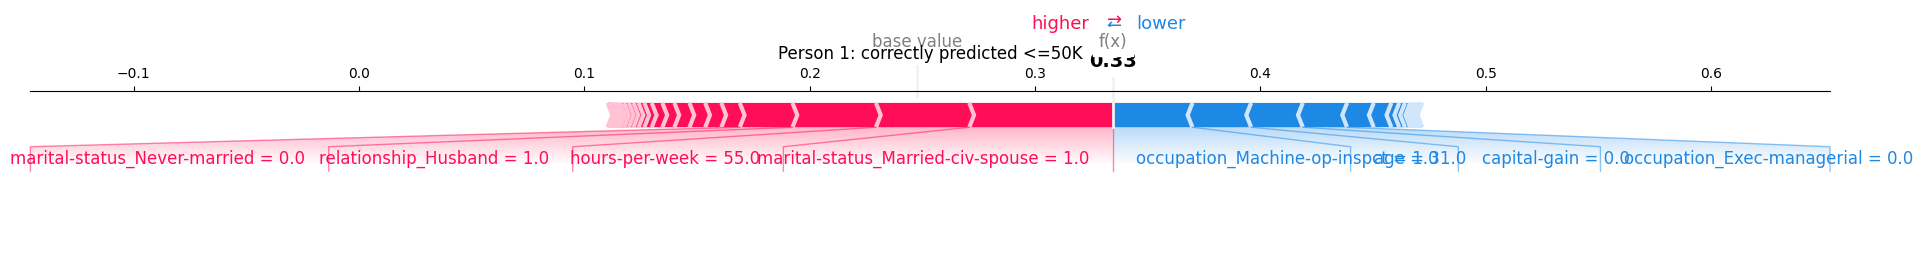

In [ ]:
test_results = pd.DataFrame({
    "true_label": y_test.values,
    "pred_label": y_pred,
    "pred_prob_>50K": y_proba
}, index=X_test.index)

correct_low_idx = test_results[
    (test_results["true_label"] == 0) & (test_results["pred_label"] == 0)
].index[0]

explain_one_case("Person 1: correctly predicted <=50K", correct_low_idx)

model correctly predicted class `$<=50K$`, because the final probability of class `$>50K$` was only `0.3345`. Some features increased the prediction, especially `marital-status_Married-civ-spouse`, `relationship_Husband`, and higher `hours-per-week`. At the same time, several important features pushed the prediction down. The strongest negative effects came from `occupation_Machine-op-inspct`, relatively lower `age`, and `capital-gain = 0`.  

This means that even though this person has some characteristics linked with higher income, they were not strong enough to move the prediction above the decision threshold.

Person 2: correctly predicted >50K
True class: >50K
Predicted class: >50K
Predicted probability of >50K: 0.8856

Original feature values:


,value
age,32
workclass,Private
fnlwgt,134737
educational-num,13
marital-status,Married-civ-spouse
occupation,Prof-specialty
relationship,Husband
race,White
gender,Male
capital-gain,99999


Top local SHAP contributions:


,feature,value,shap_value,abs_shap
3,capital-gain,99999.0,0.344209,0.344209
2,educational-num,13.0,0.077254,0.077254
15,marital-status_Married-civ-spouse,1.0,0.052096,0.052096
29,occupation_Prof-specialty,1.0,0.037392,0.037392
34,relationship_Husband,1.0,0.032684,0.032684
5,hours-per-week,50.0,0.030882,0.030882
17,marital-status_Never-married,0.0,0.022798,0.022798
23,occupation_Exec-managerial,0.0,-0.009177,0.009177
37,relationship_Own-child,0.0,0.008723,0.008723
35,relationship_Not-in-family,0.0,0.007397,0.007397


<Figure size 1500x350 with 0 Axes>

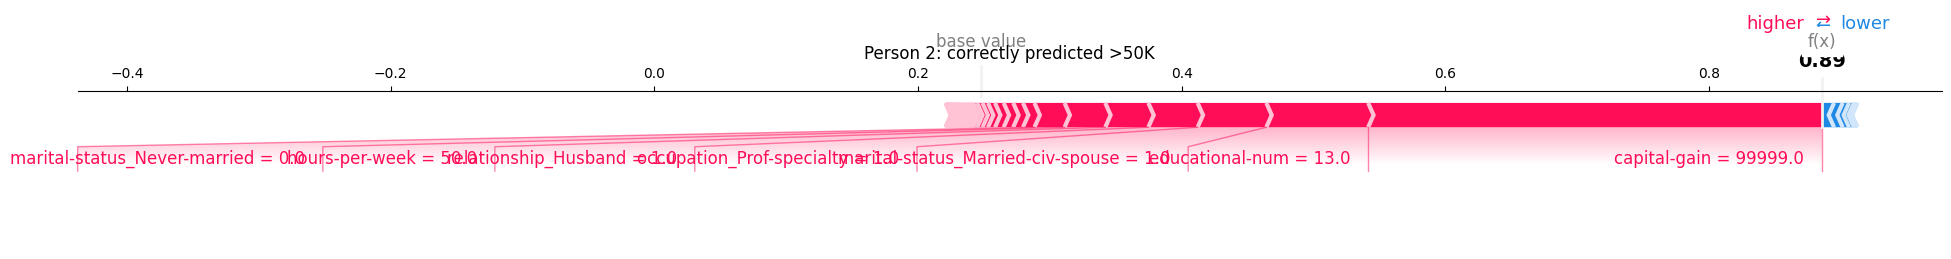

In [ ]:
correct_high_idx = test_results[
    (test_results["true_label"] == 1) & (test_results["pred_label"] == 1)
].index[0]
explain_one_case("Person 2: correctly predicted >50K", correct_high_idx)

For Person 2, the model correctly predicted class `>50K`, mainly because of the very strong positive effect of `capital-gain = 99999` (which could be mistake!), supported by higher `educational-num`, `marital-status_Married-civ-spouse`, and `occupation_Prof-specialty`.

These positive contributions clearly pushed the prediction toward high income, giving a final probability of `0.8856`.

Person 3: incorrectly predicted >50K
True class: <=50K
Predicted class: >50K
Predicted probability of >50K: 0.7463

Original feature values:


,value
age,55
workclass,Self-emp-not-inc
fnlwgt,145574
educational-num,9
marital-status,Divorced
occupation,Exec-managerial
relationship,Not-in-family
race,White
gender,Male
capital-gain,34095


Top local SHAP contributions:


,feature,value,shap_value,abs_shap
3,capital-gain,34095.0,0.478929,0.478929
15,marital-status_Married-civ-spouse,0.0,-0.044507,0.044507
5,hours-per-week,60.0,0.042143,0.042143
23,occupation_Exec-managerial,1.0,0.034399,0.034399
34,relationship_Husband,0.0,-0.031554,0.031554
0,age,55.0,0.031302,0.031302
2,educational-num,9.0,-0.029534,0.029534
13,marital-status_Divorced,1.0,-0.012551,0.012551
17,marital-status_Never-married,0.0,0.011777,0.011777
10,workclass_Self-emp-not-inc,1.0,-0.009461,0.009461


<Figure size 1500x350 with 0 Axes>

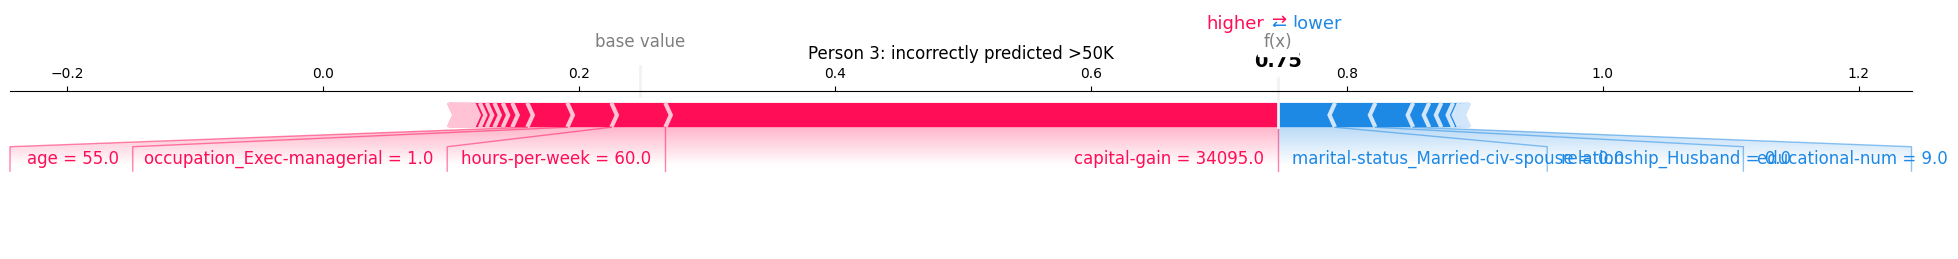

In [ ]:
uncorrect_idx = test_results[
    (test_results["true_label"] == 0) & (test_results["pred_label"] == 1)
].index[0]
explain_one_case("Person 3: incorrectly predicted >50K", uncorrect_idx)

here, the model made a wrong prediction and classified this person as `>50K`, mainly because `capital-gain = 34095` had a very strong positive impact on the output. Higher `hours-per-week`, `occupation_Exec-managerial`, and older age also pushed the prediction toward the positive class. At the same time, lower `educational-num`, `marital-status_Divorced`, and the absence of categories such as `Married-civ-spouse` and `Husband` decreased the prediction.

Unfornutatly, these negative effects were weaker than the strong positive contribution of `capital-gain`.

### **Task 2**

we will use a pre-trained ResNet model trained on ImageNet. The goal is to select 5 images from different classes and explain model predictions with LIME, then to check which image regions were the most important for the predicted class. for this reason, we visualize combined pixels that contribute the most to the final decision and discuss whether the explanations are reasonable from a our point of view

Let's load some images from skimage.

In [ ]:
def to_rgb_uint8(image):
    image = np.array(image)

    if image.ndim == 2:
        image = np.stack([image] * 3, axis=-1)

    if image.shape[-1] == 4:
        image = image[:, :, :3]

    if image.dtype == bool:
        image = image.astype(np.uint8) * 255
    elif image.dtype != np.uint8:
        if image.max() <= 1.0:
            image = (image * 255).astype(np.uint8)
        else:
            image = image.astype(np.uint8)

    return image

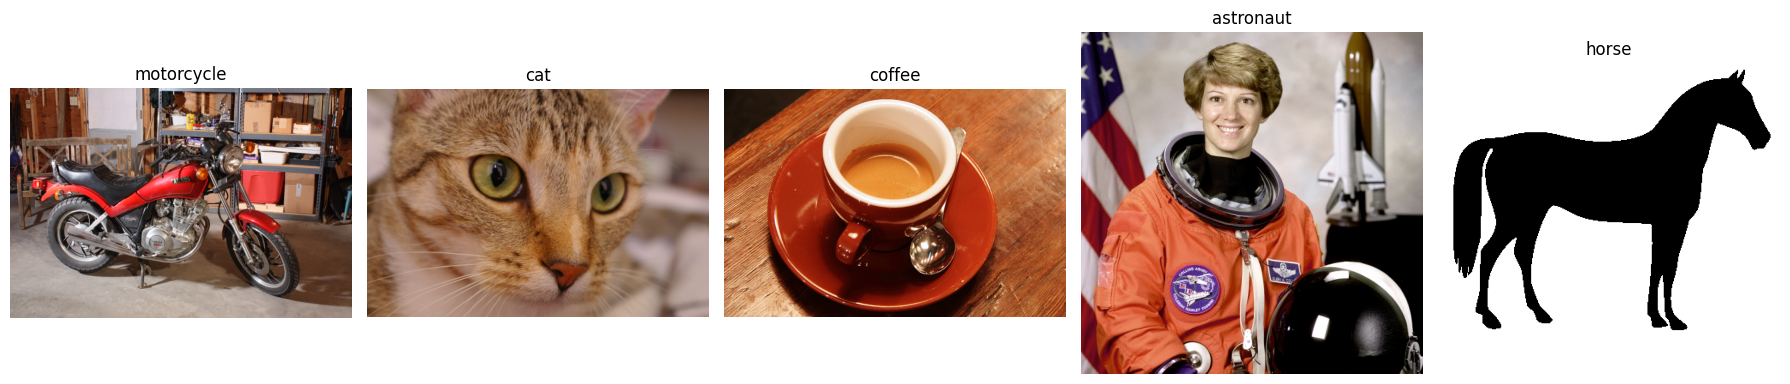

In [ ]:
images = {
    "motorcycle": to_rgb_uint8(skimage.data.stereo_motorcycle()[1]),
    "cat": to_rgb_uint8(skimage.data.chelsea()),
    "coffee": to_rgb_uint8(skimage.data.coffee()),
    "astronaut": to_rgb_uint8(skimage.data.astronaut()),
    "horse": to_rgb_uint8(skimage.data.horse()),
}

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
ax = axes.ravel()

for i, (name, image) in enumerate(images.items()):
    ax[i].imshow(image)
    ax[i].set_title(name)
    ax[i].axis("off")

fig.tight_layout()
plt.show()

Now we load the pre-trained ResNet50 model with ImageNet weights. We also prepare preprocessing functions and class names.  

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

weights = ResNet50_Weights.DEFAULT
model = models.resnet50(weights=weights)
model = model.to(device)
model.eval()

preprocess = weights.transforms()
class_names = weights.meta["categories"]

Device: cpu
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/piotr/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 64.6MB/s]


Now we define a function for prediction of a single image. It returns predicted class, confidence score, and full probability vector.

In [ ]:
def predict_single_image(image_np):
    image_pil = Image.fromarray(image_np)
    input_tensor = preprocess(image_pil).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        probabilities = torch.softmax(output, dim=1)[0].cpu().numpy()

    class_idx = int(np.argmax(probabilities))
    class_name = class_names[class_idx]
    confidence = float(probabilities[class_idx])

    return class_idx, class_name, confidence, probabilities

Let's test it for our pictures

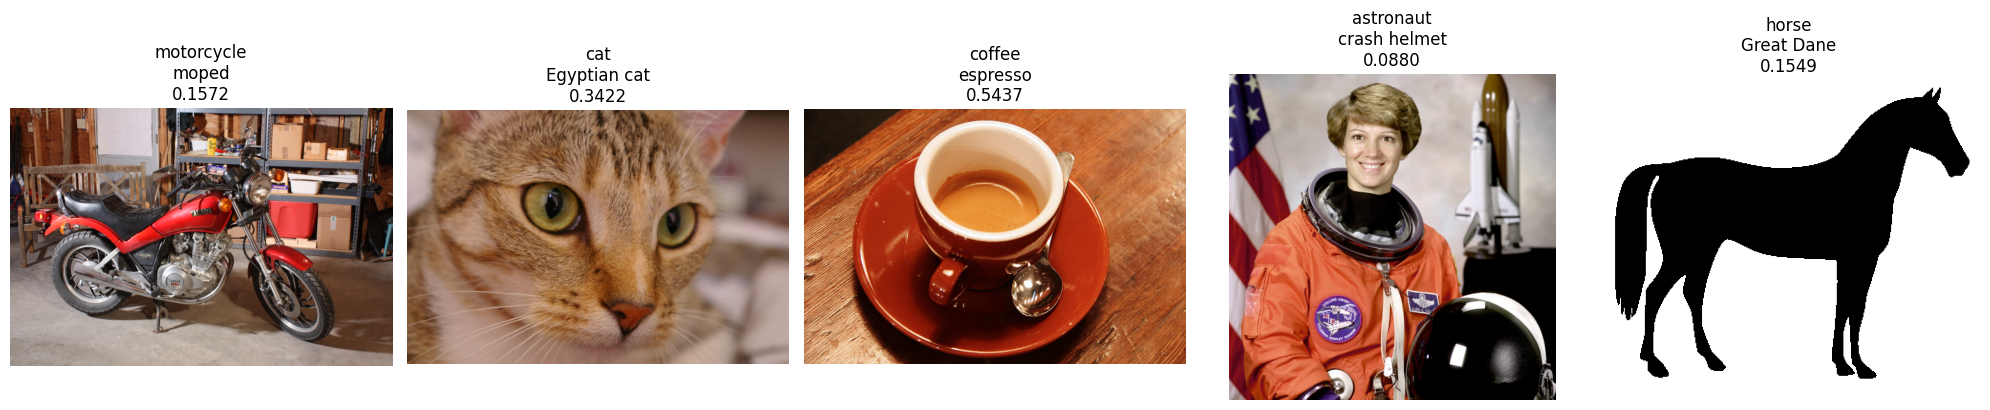

In [ ]:
results = []

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
ax = axes.ravel()

for i, (name, image_np) in enumerate(images.items()):
    class_idx, class_name, confidence, probabilities = predict_single_image(image_np)

    results.append({
        "image": name,
        "predicted_class": class_name,
        "confidence": confidence
    })

    ax[i].imshow(image_np)
    ax[i].set_title(f"{name}\n{class_name}\n{confidence:.4f}")
    ax[i].axis("off")

fig.tight_layout()
plt.show()

Now we will use LIME (Local Interpretable Model-agnostic Explanations). It is a method used to explain single predictions of complex models.

For images, LIME works by creating many slightly changed versions of the original image. Then it checks how the model prediction changes when some image regions are hidden or modified. Based on this, LIME estimates which parts of the image were the most important for the predicted class.

In [ ]:
def predict_batch_for_lime(images_np):
    batch_tensors = []

    for image_np in images_np:
        image_np = np.clip(image_np, 0, 255).astype(np.uint8)
        image_pil = Image.fromarray(image_np)
        input_tensor = preprocess(image_pil)
        batch_tensors.append(input_tensor)

    batch = torch.stack(batch_tensors).to(device)

    with torch.no_grad():
        outputs = model(batch)
        probabilities = torch.softmax(outputs, dim=1).cpu().numpy()

    return probabilities

explainer = lime_image.LimeImageExplainer(random_state=random_state)

segmenter = partial(
    slic,
    n_segments=100,
    compactness=8,
    sigma=1,
    start_label=0
)

Now we apply LIME to our images.

  0%|          | 0/2000 [00:00<?, ?it/s]

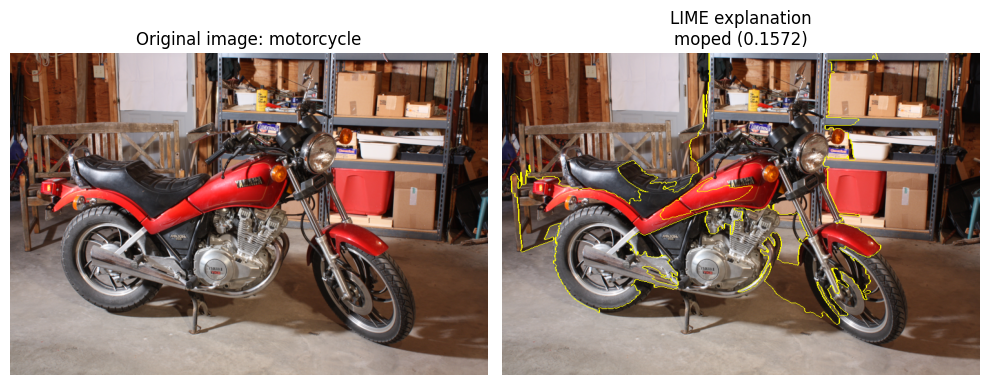

  0%|          | 0/2000 [00:00<?, ?it/s]

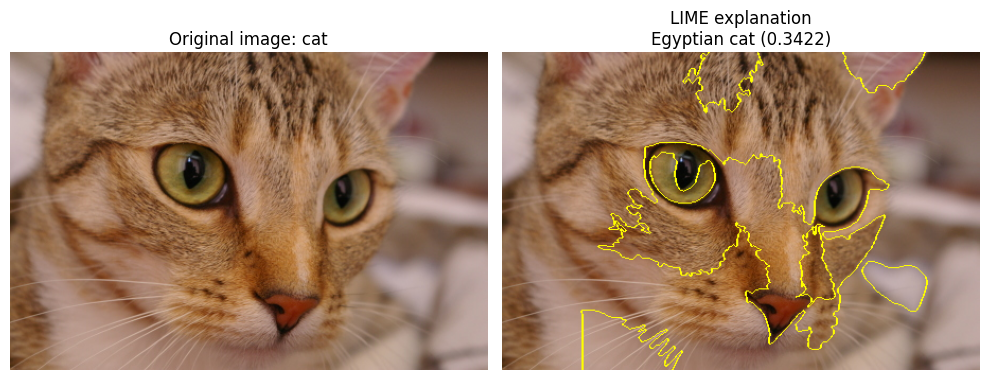

  0%|          | 0/2000 [00:00<?, ?it/s]

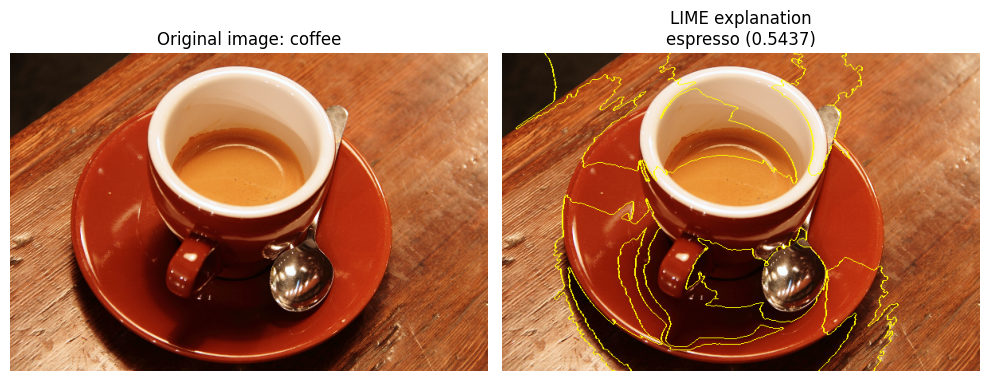

  0%|          | 0/2000 [00:00<?, ?it/s]

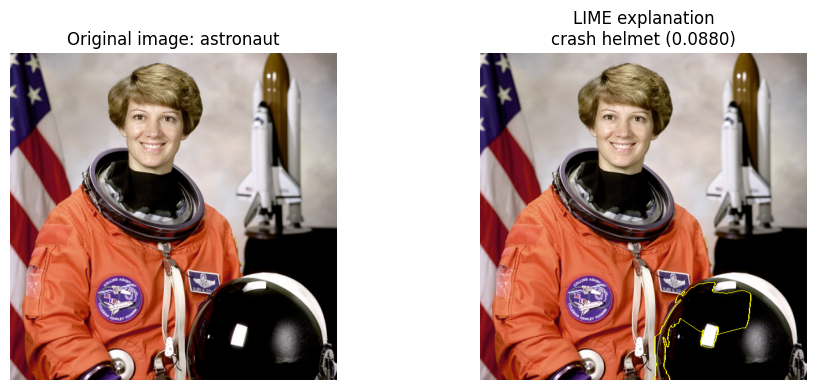

  0%|          | 0/2000 [00:00<?, ?it/s]

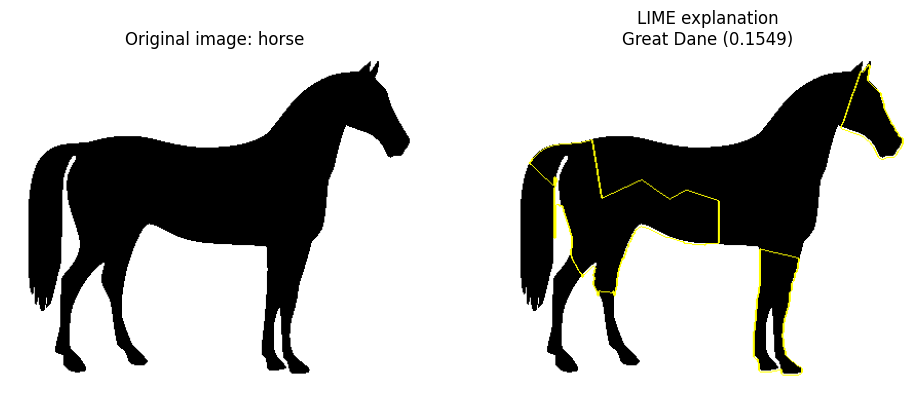

In [ ]:
lime_results = []

for name, image_np in images.items():
    class_idx, class_name, confidence, probabilities = predict_single_image(image_np)

    explanation = explainer.explain_instance(
        image=image_np.astype(np.double),
        classifier_fn=predict_batch_for_lime,
        top_labels=5,
        hide_color=None,
        num_samples=2000,
        segmentation_fn=segmenter
    )

    temp, mask = explanation.get_image_and_mask(
        label=class_idx,
        positive_only=True,
        num_features=15,
        hide_rest=False,
        min_weight=0.01
    )

    explained_image = mark_boundaries(np.clip(temp / 255.0, 0, 1), mask)

    lime_results.append({
        "image": name,
        "predicted_class": class_name,
        "confidence": confidence
    })

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].imshow(image_np)
    axes[0].set_title(f"Original image: {name}")
    axes[0].axis("off")

    axes[1].imshow(explained_image)
    axes[1].set_title(f"LIME explanation\n{class_name} ({confidence:.4f})")
    axes[1].axis("off")

    fig.tight_layout()
    plt.show()

The LIME explanations partially align with human intuition, although the alignment is not perfect in all cases. For motorcycle and coffee, the highlighted regions correspond to visually meaningful parts of the objects. For example, the model focuses on components like the motorcycle’s wheels, engine area, and the edges of the cup and saucer. These are features that a human observer would also likely consider important when identifying these objects.

However, in some cases the highlighted regions include parts of the background or areas that are not clearly related to the main object. For instance, in the cat image some explanations appear around surrounding textures.

### **Task 3**

We are going to generate counterfactual explanations for a credit approval model.

First we need to preprocess the dataset. We are using German Credit dataset from Kaggle.

In [3]:
df_credit = pd.read_csv('./../datasets/german_credit_risk.csv')
display(df_credit.head())
df_credit = df_credit.drop(columns=['Unnamed: 0'])

# Fill NaN values so the Neural Network and DiCE don't crash.
df_credit.fillna("Unknown", inplace=True)

# Map target and force to int
target_col = 'target'
df_credit[target_col] = df_credit['Risk'].map({'good': 1, 'bad': 0}).astype(int)
df_credit.drop(columns=['Risk'], inplace=True)

# Split data
X_credit = df_credit.drop(columns=[target_col])
y_credit = df_credit[target_col]

# Define columns based strictly on X_credit
num_cols = X_credit.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_credit.select_dtypes(include=['category', 'object']).columns.tolist()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


Now we can move on to defining the preprocessor for the Neural Network and splitting the data.

In [4]:
nn_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop='if_binary', handle_unknown="ignore", sparse_output=False), cat_cols)
    ],
    verbose_feature_names_out=False
)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_credit, y_credit, 
    test_size=0.2, 
    random_state=random_state, 
    stratify=y_credit
)

print(f"Train set: {X_train_c.shape}")
print(f"Test set: {X_test_c.shape}")

Train set: (800, 9)
Test set: (200, 9)


Now we train the Neural Network on the train set.

In [5]:
nn_model = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=random_state)

pipeline = Pipeline(steps=[
    ('preprocessor', nn_preprocessor),
    ('classifier', nn_model)
])

pipeline.fit(X_train_c, y_train_c)

# Quick check of accuracy
credit_accuracy = accuracy_score(y_test_c, pipeline.predict(X_test_c))
print(f"Neural Network Accuracy on Test Set: {credit_accuracy:.4f}")

Neural Network Accuracy on Test Set: 0.6650


The accuracy equal to ~0.65 is significantly better than random guessing, but it's far from perfect.

Now we make our predictions, filter for rejected applications and select the first 5 rejected applications.

In [6]:
y_pred_c = pipeline.predict(X_test_c)

rejected_mask = (y_pred_c == 0)
X_rejected = X_test_c[rejected_mask]
X_rejected_5 = X_rejected.head(5)

print("Original Data for 5 Rejected Applicants:")
display(X_rejected_5[['Age', 'Credit amount', 'Duration', 'Purpose']])

Original Data for 5 Rejected Applicants:


,Age,Credit amount,Duration,Purpose
257,29,2149,12,radio/TV
122,24,1768,12,furniture/equipment
950,40,3590,18,business
650,50,7476,48,education
239,39,2522,30,radio/TV


At this moment we can finally initialize Dice data and model on the training set. Then we generate counterfactuals, but focusing strictly on the feature that can be changed or negotiated by the applicants.

In [7]:
df_train_dice = pd.concat([X_train_c, y_train_c], axis=1)
d = dice_ml.Data(dataframe=df_train_dice, continuous_features=num_cols, outcome_name=target_col)
m = dice_ml.Model(model=pipeline, backend="sklearn")

# Initialize the Explainer
exp = dice_ml.Dice(d, m, method="random")

actionable_features = ['Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose']

permitted_ranges = {
    'Credit amount': [500, 4000],
    'Duration': [6, 24]
}

dice_exp = exp.generate_counterfactuals(
    X_rejected_5, 
    total_CFs=3,
    desired_class="opposite", 
    features_to_vary=actionable_features,
    permitted_range=permitted_ranges,
    random_seed=random_state
)

print("Counterfactual Explanations (What to change to get approved):")
dice_exp.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 5/5 [00:02<00:00,  2.35it/s]

Counterfactual Explanations (What to change to get approved):
Query instance (original outcome : 0)


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,target
0,29,male,2,free,little,little,2149,12,radio/TV,0



Diverse Counterfactual set (new outcome: 1)


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,target
0,-,-,-,-,-,moderate,-,-,-,1
1,-,-,-,-,-,moderate,-,-,-,1
2,-,-,-,-,-,Unknown,-,-,-,1


...

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,target
0,-,-,-,-,quite rich,-,-,-,business,1
1,-,-,-,-,-,-,-,17,-,1
2,-,-,-,-,-,rich,-,20,-,1


Query instance (original outcome : 0)


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,target
0,39,male,2,own,little,little,2522,30,radio/TV,0



Diverse Counterfactual set (new outcome: 1)


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,target
0,-,-,-,-,-,Unknown,1744,-,-,1
1,-,-,-,-,-,-,-,19,furniture/equipment,1
2,-,-,-,-,-,Unknown,-,10,-,1


Conclusions:

For Applicant 1, simply moving the `Checking account` from "little" to "moderate" or "Unknown" flips the decision entirely without changing anything else. Applicant 3 gets approved by upgrading `Saving accounts` to "rich". The model heavily relies on immediate financial buffers to offset default risk.

When financial health cannot be drastically improved, the counterfactuals suggest reducing the bank's exposure, particularly the loan term. For Applicants 3, 4, and 5, shortening the payback period is a very strong lever (for instance, drastically cutting Applicant 4's `Duration` from 48 months down to 17 or 20 months). Similarly, for Applicants 2 and 5, reducing the requested `Credit amount` (e.g., from 2522 to 1744) leads to approval.

Now we are going to visualize feature importances using SHAP.

  0%|          | 0/5 [00:00<?, ?it/s]

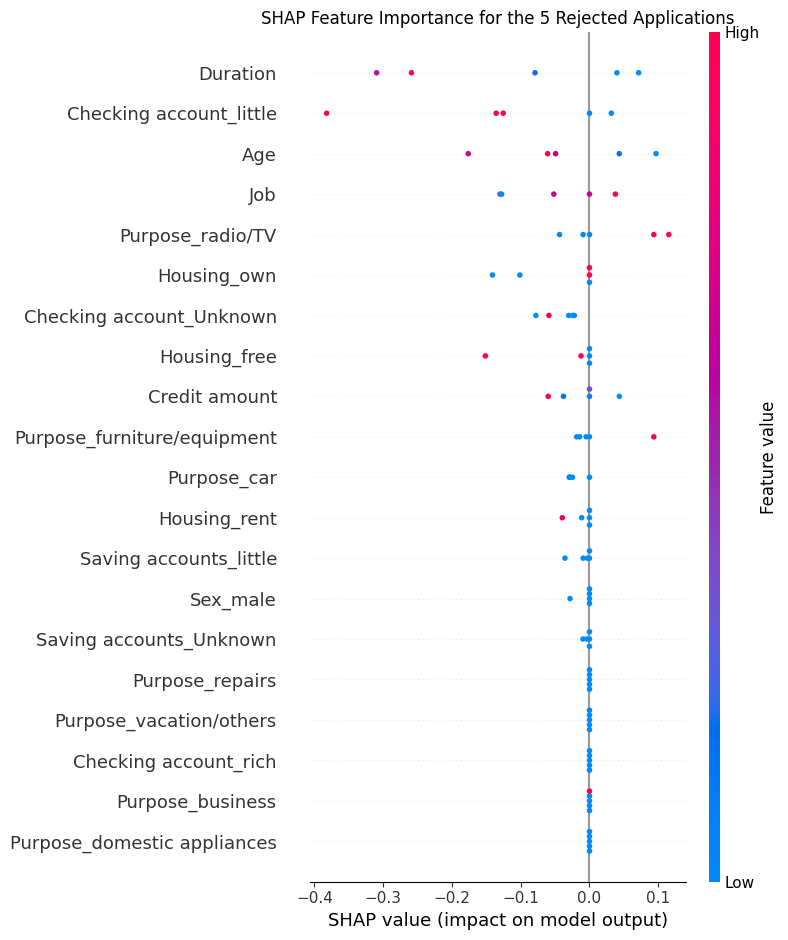

In [8]:
# Preprocess data for SHAP
X_train_c_enc = nn_preprocessor.transform(X_train_c)
X_rejected_5_enc = nn_preprocessor.transform(X_rejected_5)
credit_feature_names = nn_preprocessor.get_feature_names_out()

# Create a background dataset using K-Means to speed up KernelExplainer
background = shap.kmeans(X_train_c_enc, 25)

predict_fn = lambda x: pipeline.named_steps['classifier'].predict_proba(x)
explainer_nn = shap.KernelExplainer(predict_fn, background)
shap_values_nn = explainer_nn.shap_values(X_rejected_5_enc)

# We want the explanations for the positive class (index 1 / Approved)
if isinstance(shap_values_nn, list):
    shap_values_nn_pos = shap_values_nn[1]
elif len(shap_values_nn.shape) == 3:
    shap_values_nn_pos = shap_values_nn[:, :, 1]
else: 
    shap_values_nn_pos = shap_values_nn

# Ensure shap_values_nn_pos is a 2D array
shap_values_nn_pos = np.array(shap_values_nn_pos)


predict_fn = lambda x: pipeline.named_steps['classifier'].predict_proba(x)
explainer_nn = shap.KernelExplainer(predict_fn, background)

plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values_nn_pos, X_rejected_5_enc, feature_names=credit_feature_names, show=False)
plt.title("SHAP Feature Importance for the 5 Rejected Applications")
plt.tight_layout()
plt.show()

Conclusions:

The features with negative SHAP values are what pushed the model's prediction toward rejection. Positively valued features actually helped push the score toward approval, even though the final decision was still a rejection.

Looking at `Duration`, the model views longer payback periods as higher risk. `Checking account_little` is a highly important feature, and it's occurence negatively affects chances to get an approval. We can also see that younger applicants have some advantage. Not having a house may also be one of the reasons to be rejected for.

Now we will visualize the first rejected person as an example, using Waterfall Plot.

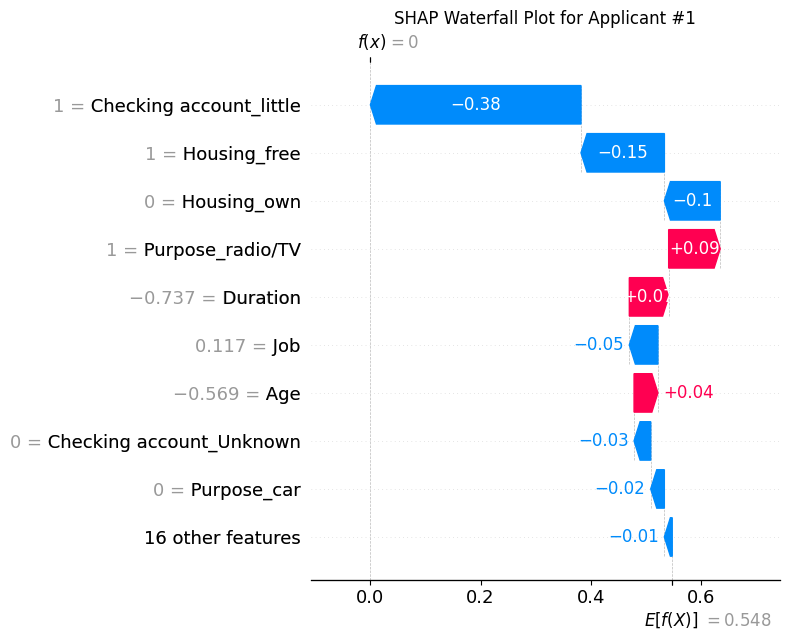

In [9]:
# Extract the expected value
expected_val = explainer_nn.expected_value
if isinstance(expected_val, (list, np.ndarray)):
    base_val = float(expected_val[1])
else:
    base_val = float(expected_val)


shap_vals_single = shap_values_nn_pos[0]
data_single = X_rejected_5_enc[0]

# Create a SHAP Explanation object required for the waterfall plot
explanation = shap.Explanation(
    values=shap_vals_single,
    base_values=base_val,
    data=data_single,
    feature_names=credit_feature_names
)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(explanation, show=False)
plt.title("SHAP Waterfall Plot for Applicant #1")
plt.tight_layout()
plt.show()

Conclusions:

$\mathbb{E}[f(X)] = 0.548$ means that, on average, the model gives a typical applicant a 54.8% chance of approval based on the training data. The model views the lack of a strong checking account as a massive indicator of high default risk, which was a deal-breaker for this applicant. Also, the model views "living rent-free" as another reason for being rejected. We can see that the purpose of the loan actually helped the applicant, even though he didn't get an approval.

### **Task 4**

In this exercise we will use a pre-trained BERT model for sentiment analysis of imdb reviews.

First we need to define the tokenizer and load the model.

In [4]:
model_name = "textattack/bert-base-uncased-imdb"

tokenizer = AutoTokenizer.from_pretrained(model_name)
# output_attentions=True is required to get the weights for visualization
model = AutoModelForSequenceClassification.from_pretrained(model_name, output_attentions=True)

# Set model to evaluation mode
model.eval()

# Check device (use GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Model loaded successfully on {device}.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded successfully on cuda.


Now we are going to use the imdb dataset to get 5 reviews.

In [5]:
imdb_dataset = datasets.load_dataset("imdb", split="test")
short_reviews = imdb_dataset.filter(lambda x: 100 < len(x['text']) < 250)

# Separate into positive (1) and negative (0)
pos_reviews = short_reviews.filter(lambda x: x['label'] == 1)
neg_reviews = short_reviews.filter(lambda x: x['label'] == 0)

# Select 5 reviews (3 Positive, 2 Negative)
reviews = [
    pos_reviews[0]['text'],
    pos_reviews[1]['text'],
    pos_reviews[2]['text'],
    neg_reviews[0]['text'],
    neg_reviews[1]['text']
]

The model needs to tokenize the text to work. It means that instead of giving up on a word it doesn't recognize, BERT breaks it down into smaller, recognizable chunks that are in its vocabulary. When BERT splits a word into subwords, it needs a way to remember that those pieces belong together and shouldn't be treated as separate, standalone words.
The first chunk of the word gets no prefix. Every subsequent chunk of that same word gets the ## prefix.

So now we need to define and run the function that: tokenizes the text, predicts the class, gets attentions of the tokens and visualizes the results.


--- Review 1 ---
While the romance in this film is an important aspect, it is largely about the role of responsibility and duty in modern Indian. All of the major characters were well fleshed out, and had their own "inner life". I recommend this strongly


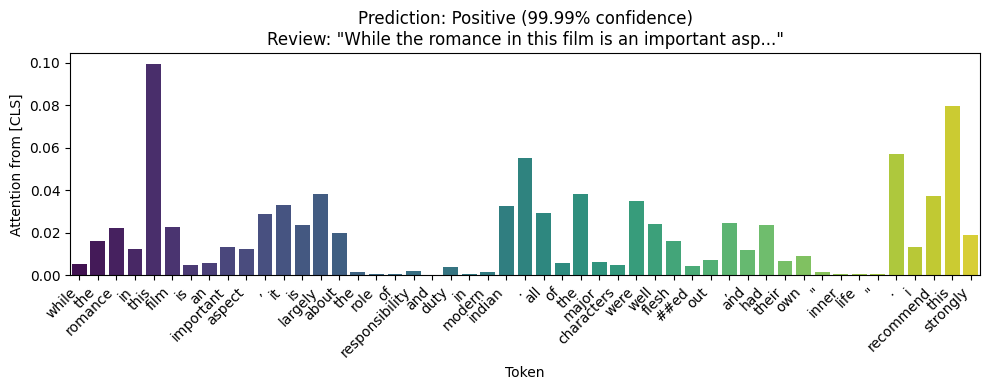


--- Review 2 ---
This short deals with a severely critical writing teacher whose undiplomatic criticism extends into his everyday life. When he learns why that's not a good idea, we learn a bit about the beautiful craft of writing that he's been lecturing on.


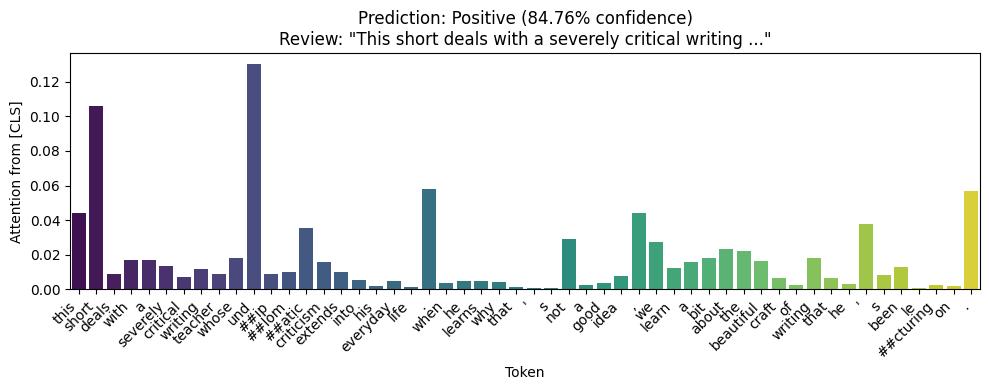


--- Review 3 ---
Extremely funny. More gags in each one of these episodes than in ten years of Friends. And with a good (ie. funny) Nordberg, not the fab-only-casted OJ Simpson in the movies. When will these episodes emerge on DVD?...


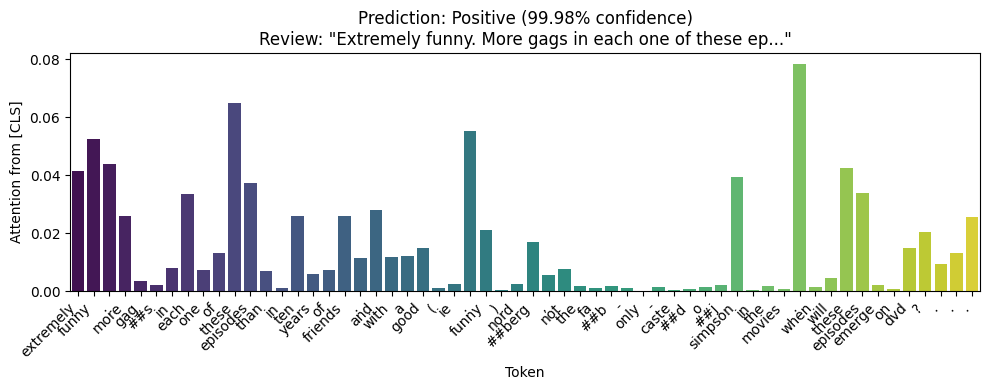


--- Review 4 ---
Widow hires a psychopath as a handyman. Sloppy film noir thriller which doesn't make much of its tension promising set-up. (3/10)


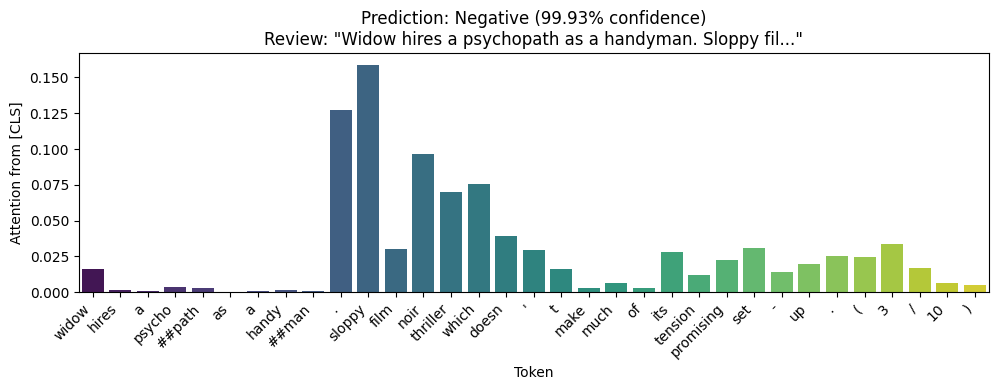


--- Review 5 ---
I found this movie really hard to sit through, my attention kept wandering off the tv. As far as romantic movies go..this one is the worst I've seen. Don't bother with it.


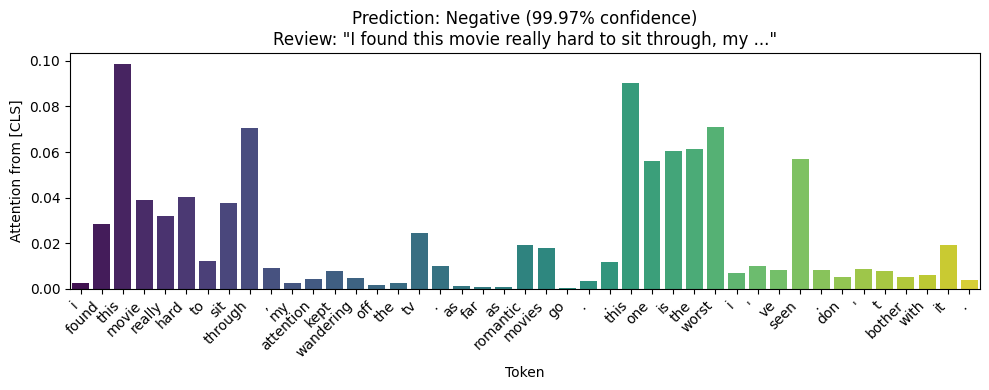

In [8]:
def analyze_and_plot_attention(text, model, tokenizer, device):
    # Tokenize text
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model(**inputs)
        
    # Get prediction
    logits = outputs.logits
    predicted_class_idx = torch.argmax(logits, dim=1).item()
    confidence = torch.softmax(logits, dim=1)[0][predicted_class_idx].item()
    sentiment = "Positive" if predicted_class_idx == 1 else "Negative"
    
    # Get attentions, we want the last layer [-1].
    last_layer_attention = outputs.attentions[-1]
    
    # Average the attention weights across all 12 heads in the last layer
    avg_attention = torch.mean(last_layer_attention, dim=1).squeeze(0).cpu().numpy()
    
    # We want to see how much the [CLS] token (index 0) attends to every other token
    cls_attention = avg_attention[0, :]
    
    # Convert token IDs back to strings for the plot
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0].cpu().numpy())
    
    df_attn = pd.DataFrame({
        'Token': tokens,
        'Attention Weight': cls_attention
    })
    
    # Filter out [CLS] and [SEP] tokens to focus only on the actual words
    ignore_tokens = ['[CLS]', '[SEP]']
    df_attn = df_attn[~df_attn['Token'].isin(ignore_tokens)]
    
    
    df_attn = df_attn.reset_index(drop=True)

    print(text)
    plt.figure(figsize=(10, 4))
    sns.barplot(x=df_attn.index, y='Attention Weight', data=df_attn, palette='viridis')
    plt.title(f"Prediction: {sentiment} ({confidence:.2%} confidence)\nReview: \"{text[:50]}...\"")
    plt.xticks(ticks=df_attn.index, labels=df_attn['Token'], rotation=45, ha='right')
    plt.ylabel("Attention from [CLS]")
    plt.xlabel("Token")
    plt.tight_layout()
    plt.show()

for i, review in enumerate(reviews):
    print(f"\n--- Review {i+1} ---")
    analyze_and_plot_attention(review, model, tokenizer, device)

The bar plots show the attention distribution across the tokens. The higher the bar is, the more important role the token played in the process of choosing a class. It is important to keep in mind that the model does not treat the tokens independently. BERT actually understands connections between the tokens, because instead of reading a sentence one word at a time, it reads the entire sentence all at once to figure out its actual context. 

Our model correctly assigned all the 5 reviews to their classes with high level of confidence. The lowest level of confidence occurred for the second positive review. When we read the text we can understand the doubts of the model, because actually the movie itself isn't rated there clearly. Also, the text contains the phrase "severely critical", which sounds highly negative, forcing the model to weigh that against positive words like "beautiful" later in the text.

Generally, when we look at the most important tokens across the reviews, we can see that the model heavily prioritizes strong descriptive adjectives and adverbs that carry clear emotional weight. For instance, in the negative reviews, words like "sloppy" and "worst" command massive attention spikes. In the positive reviews, words like "recommend", "strongly", "beautiful", and "funny" create similar peaks.

However, as we mentioned before, BERT does not just act as a simple keyword spotter. It also assigns significant attention to subject nouns and demonstrative pronouns (such as "this", "characters", or "episodes"). This visually confirms that the model is linking the emotional descriptors directly to the subjects they modify in order to grasp the complete meaning of the review.

We can also check how well our model performs on average, by testing it's accuracy on a larger, random sample of reviews. 

Predicting:   0%|          | 0/63 [00:00<?, ?it/s]

Final Model Accuracy: 93.20%


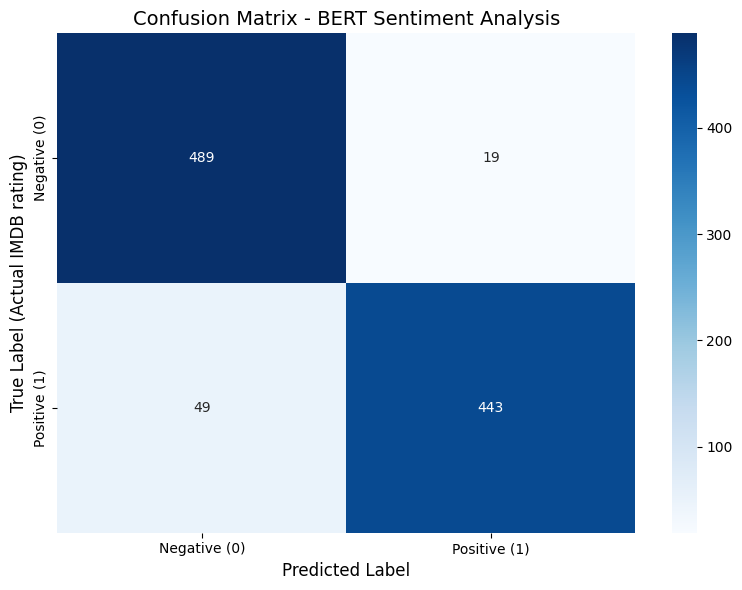

In [9]:
def evaluate_and_plot_confusion_matrix(dataset, model, tokenizer, device, batch_size=16):
    model.eval()
    all_preds = []
    all_labels = []
    
    # Tokenize data in bulk
    def tokenize_function(examples):
        return tokenizer(
            examples["text"], 
            padding="max_length", 
            truncation=True, 
            max_length=512
        )
    tokenized_dataset = dataset.map(tokenize_function, batched=True)
    tokenized_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
    
    dataloader = DataLoader(tokenized_dataset, batch_size=batch_size)
    
    
    # Run the evaluation and collect predictions
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Predicting"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    print(f"Final Model Accuracy: {accuracy:.2%}")
    
    cm = confusion_matrix(all_labels, all_preds)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, 
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Negative (0)', 'Positive (1)'], 
        yticklabels=['Negative (0)', 'Positive (1)']
    )
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label (Actual IMDB rating)', fontsize=12)
    plt.title('Confusion Matrix - BERT Sentiment Analysis', fontsize=14)
    plt.tight_layout()
    plt.show()

eval_dataset = imdb_dataset.shuffle(seed=random_state).select(range(1000))
evaluate_and_plot_confusion_matrix(eval_dataset, model, tokenizer, device)

~93% accuracy shows that the model is very good at recognizing crucial words and patterns and most of the time it is able to clasify the reviews correctly. The model clasifies postive reviews as negative more times (49 occurences), than negative reviews as positive (only 19 times).